In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the 4 prediction datasets
datasets = {
    "03": pd.read_csv("dataset_03_predictions.csv"),
    "04": pd.read_csv("dataset_04_predictions.csv"),
    "06": pd.read_csv("dataset_06_predictions.csv"),
    "08": pd.read_csv("dataset_08_predictions.csv")
}

def compute_long_warm_periods(df, threshold=15):
    """
    For each year, count the number of warm periods (consecutive days with Tmax_pred >= 15°C)
    that last for MORE THAN 3 days.
    Returns a DataFrame with columns: year, num_long_warm_periods
    """
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)

    df["Tmax_pred"] = df["prediction"]
    df["warm"] = df["Tmax_pred"] >= threshold

    # Identify consecutive warm streaks (groups)
    df["warm_group"] = (df["warm"] != df["warm"].shift(1)).cumsum()

    # Only keep warm days and compute start/end DOY for each streak
    warm_days = df[df["warm"]]
    if warm_days.empty:
        return pd.DataFrame({"year": [], "num_long_warm_periods": []})

    period_stats = warm_days.groupby(["year", "warm_group"]).agg(
        start_doy=("dayofyear", "min"),
        end_doy=("dayofyear", "max")
    ).reset_index()

    # Duration in days = number of days in the streak (inclusive)
    # (matches the spirit of "heat periods that last for more than three days")
    period_stats["duration_days"] = period_stats["end_doy"] - period_stats["start_doy"] + 1

    # Keep only periods longer than 3 days
    long_periods = period_stats[period_stats["duration_days"] > 3]

    # Count how many such long periods exist per year
    num_long = long_periods.groupby("year").size().reset_index(name="num_long_warm_periods")

    return num_long


# Compute the metric for all 4 datasets
results = {}
for name, df in datasets.items():
    results[name] = compute_long_warm_periods(df)

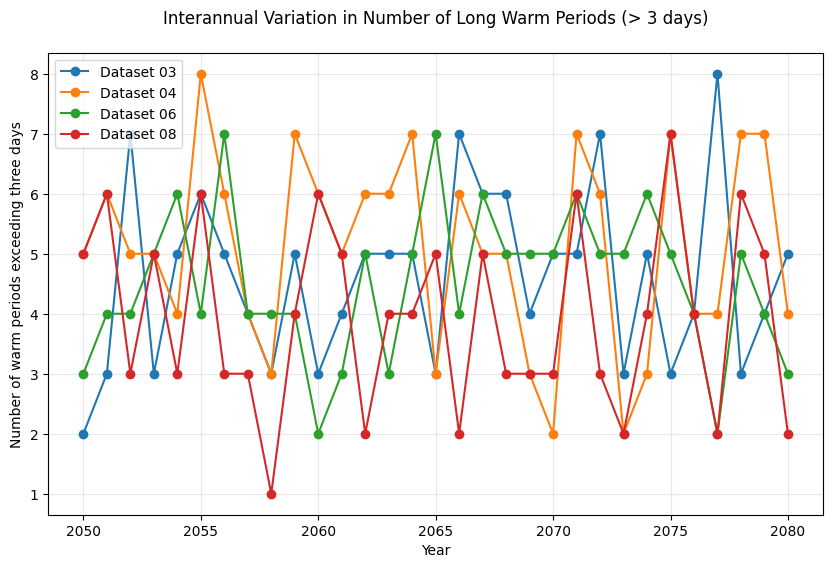

In [11]:
# ========================
# PLOT 1: Line plot
# ========================
plt.figure(figsize=(10, 6))

for name, df in results.items():
    plt.plot(df["year"], df["num_long_warm_periods"], marker='o', label=f"Dataset {name}")

plt.xlabel("Year")
plt.ylabel("Number of warm periods exceeding three days")
plt.title("Interannual Variation in Number of Long Warm Periods (> 3 days)\n"
          )
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#Interpretation:

There is moderate interannual variability in the frequency of prolonged warm spells, typically ranging from 2 to 8 events per year. While no strong long-term trend is visible, some years (e.g., ~2055, ~2077) show clear peaks. The datasets diverge notably in certain years, indicating uncertainty among models regarding the occurrence of extended warm periods.

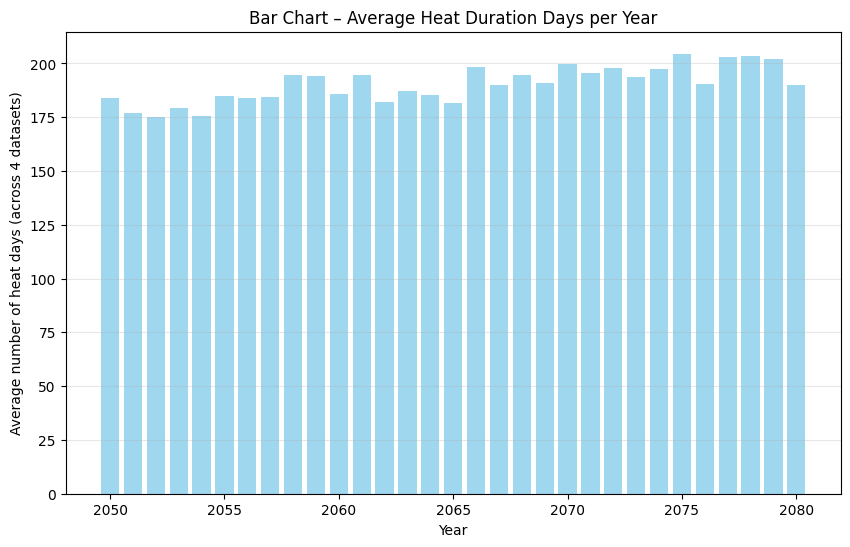

In [6]:
 # ========================
# PLOT 2: Bar chart of total heat duration days
# ========================
def compute_total_heat_days(df, threshold=15):
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])
    df["warm"] = df["prediction"] >= threshold
    total_days = df[df["warm"]].groupby("year").size().reset_index(name="total_heat_days")
    return total_days

# Average across the 4 datasets (To make the bar chart clean)
all_heat_days = []
for name, df in datasets.items():
    days_df = compute_total_heat_days(df)
    days_df["dataset"] = name
    all_heat_days.append(days_df)

combined = pd.concat(all_heat_days)
avg_heat_days = combined.groupby("year")["total_heat_days"].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(avg_heat_days["year"], avg_heat_days["total_heat_days"], color="skyblue", alpha=0.8)
plt.xlabel("Year")
plt.ylabel("Average number of heat days (across 4 datasets)")
plt.title("Bar Chart – Average Heat Duration Days per Year")
plt.grid(axis="y", alpha=0.3)
plt.show()

#Interpretation:
On average, there are 175–205 warm days per year throughout the 2050–2080 period. This suggests consistently long warm seasons in the future, with a slight upward tendency in the late 2070s. Overall, roughly half the year or more is expected to be under warm conditions, indicating a significantly extended warm period annually.

### Optional: Comparison of Total Heat Duration Days Across Individual Datasets

Visualization of the total number of heat days for each year by individual dataset. This allows for a direct comparison of how heat duration varies between the different datasets rather than showing an average above

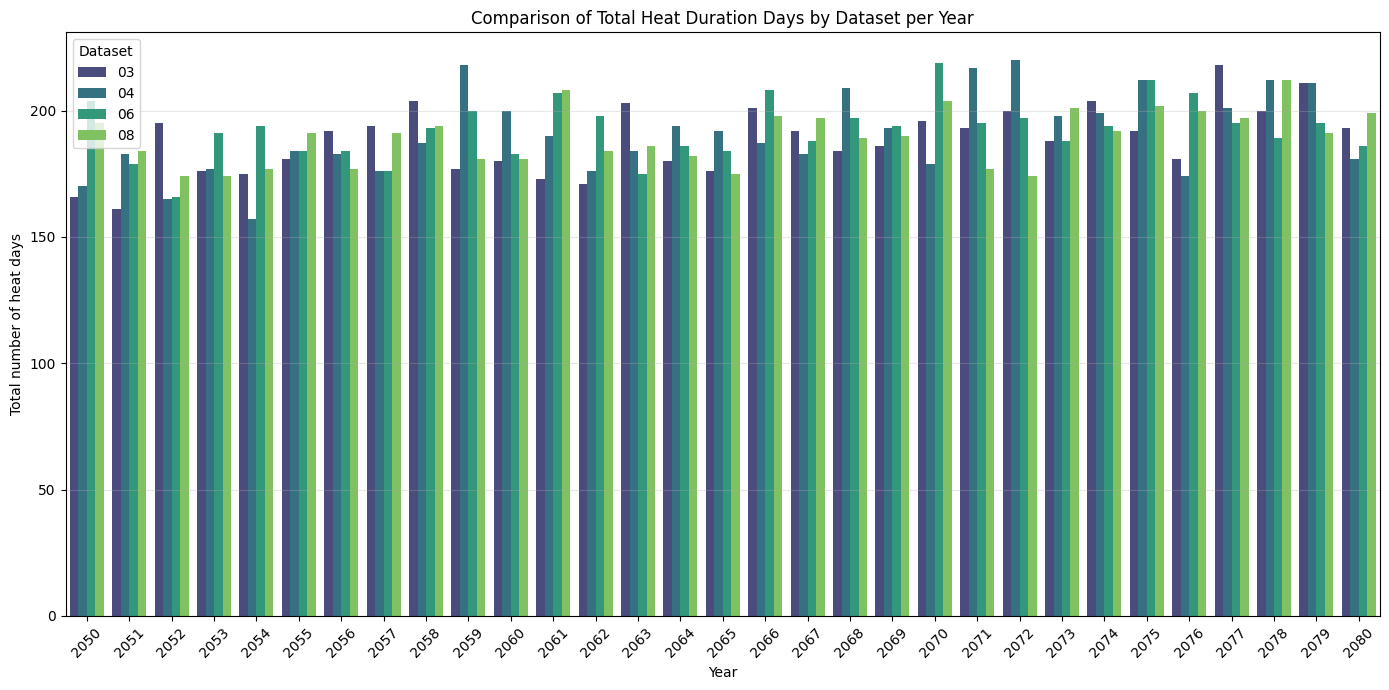

In [10]:
plt.figure(figsize=(14, 7))
sns.barplot(x='year', y='total_heat_days', hue='dataset', data=combined, palette='viridis')
plt.xlabel('Year')
plt.ylabel('Total number of heat days')
plt.title('Comparison of Total Heat Duration Days by Dataset per Year')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#Interpretation:

All four datasets show broadly similar behavior (mostly 170–210 heat days/year), suggesting good agreement on the overall length of the warm season. However, noticeable differences between datasets appear in some years (e.g., 2058, 2070–2072), highlighting model uncertainty in the exact number of warm days. The general consistency implies robust projections for a warmer future climate.